# Prever quantas bicicletas serão alugadas no futuro

Será utilizado as datas do passado para treinar o programa para então prever as contagens de bicicletas em datas futuras

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
bike = pd.read_csv("C:\\Users\\User\\Desktop\\Data Science\\Machine Learning Deep Learning\\Previsao com Keras\\bicicletas.csv")


In [3]:
bike.head()

,datas,contagem,temperatura,sensacao,umidade,vel_vento,clima,feriado,final_ds,estacao
0,2015-01-04 00:00:00,182,3.0,2.0,93.0,6.0,3.0,0.0,1.0,3.0
1,2015-01-04 01:00:00,138,3.0,2.5,93.0,5.0,1.0,0.0,1.0,3.0
2,2015-01-04 02:00:00,134,2.5,2.5,96.5,0.0,1.0,0.0,1.0,3.0
3,2015-01-04 03:00:00,72,2.0,2.0,100.0,0.0,1.0,0.0,1.0,3.0
4,2015-01-04 04:00:00,47,2.0,0.0,93.0,6.5,1.0,0.0,1.0,3.0


In [4]:
# convertendo as datas
bike['datas'] = pd.to_datetime(bike['datas'])

(array([16436., 16526., 16617., 16709., 16801., 16892., 16983., 17075.,
        17167.]),
 [Text(16436.0, 0, '2015-01'),
  Text(16526.0, 0, '2015-04'),
  Text(16617.0, 0, '2015-07'),
  Text(16709.0, 0, '2015-10'),
  Text(16801.0, 0, '2016-01'),
  Text(16892.0, 0, '2016-04'),
  Text(16983.0, 0, '2016-07'),
  Text(17075.0, 0, '2016-10'),
  Text(17167.0, 0, '2017-01')])

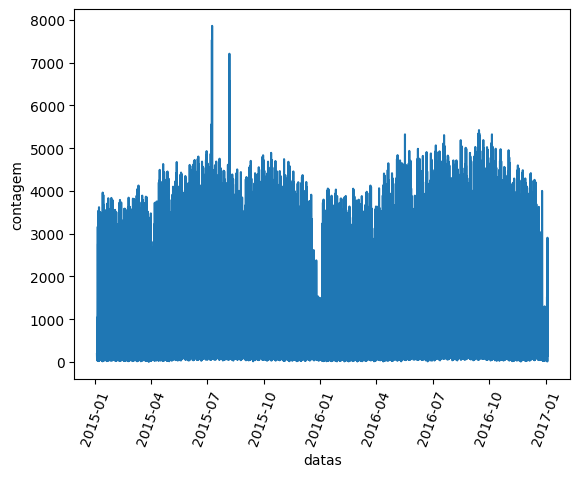

In [5]:
sns.lineplot(x='datas', y='contagem', data=bike)
plt.xticks(rotation=70)

# ESCALAR OS DADOS

In [6]:
from sklearn.preprocessing import StandardScaler

In [7]:
sc2 = StandardScaler()

# Ajuste dos dados

In [8]:
sc2.fit(bike['contagem'].values.reshape(-1,1))

,copy,True
,with_mean,True
,with_std,True


In [9]:
# Y é a Saída da Rede Neural
y = sc2.transform(bike['contagem'].values.reshape(-1,1))

In [10]:
tamanho_treino = int(len(bike)*0.9)
tamanho_teste = len(bike) - tamanho_treino

In [11]:
ytreino = y[0:tamanho_treino]

In [12]:
yteste = y[tamanho_treino:len(bike)]

(array([16436., 16526., 16617., 16709., 16801., 16892., 16983., 17075.,
        17167.]),
 [Text(16436.0, 0, '2015-01'),
  Text(16526.0, 0, '2015-04'),
  Text(16617.0, 0, '2015-07'),
  Text(16709.0, 0, '2015-10'),
  Text(16801.0, 0, '2016-01'),
  Text(16892.0, 0, '2016-04'),
  Text(16983.0, 0, '2016-07'),
  Text(17075.0, 0, '2016-10'),
  Text(17167.0, 0, '2017-01')])

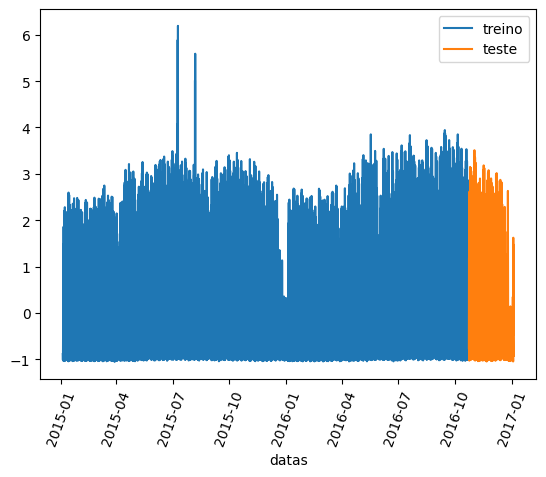

In [13]:
sns.lineplot(x='datas', y=ytreino[:,0], data=bike[0:tamanho_treino],label='treino')
sns.lineplot(x='datas', y=yteste[:,0], data=bike[tamanho_treino:len(bike)],label='teste')
plt.xticks(rotation=70)

# Separar os dados

vamos passar os dados de contagem somente como a entrada e como saída da rede neural.

In [14]:
import numpy as np

In [15]:
def separa_dados(vetor,n_passos):
    x_novo, y_novo = [], []
    
    for i in range(n_passos, vetor.shape[0]):
        x_novo.append(list(vetor.loc[i-n_passos:i-1]))
        y_novo.append(vetor.loc[i])
    x_novo, y_novo = np.array(x_novo), np.array(y_novo)
    return x_novo, y_novo

Separa Dados Treino:

In [16]:
vetor = pd.DataFrame(ytreino)[0]

In [17]:
# Separa Dados do Treino
xtreino_novo, ytreino_novo = separa_dados(vetor,10)

In [18]:
xtreino_novo

array([[-0.88574518, -0.9262953 , -0.92998167, ..., -0.9843557 ,
        -0.93274645, -0.77607553],
       [-0.9262953 , -0.92998167, -0.98712048, ..., -0.93274645,
        -0.77607553, -0.56687377],
       [-0.92998167, -0.98712048, -1.01016032, ..., -0.77607553,
        -0.56687377, -0.38347663],
       ...,
       [-0.02774148, -0.29131727, -0.4323211 , ..., -0.72630948,
        -0.8534894 , -0.91523618],
       [-0.29131727, -0.4323211 , -0.51065656, ..., -0.8534894 ,
        -0.91523618, -0.9548647 ],
       [-0.4323211 , -0.51065656, -0.55212827, ..., -0.91523618,
        -0.9548647 , -0.9548647 ]], shape=(15662, 10))

Separa Dados Teste:

In [19]:
vetor2 = pd.DataFrame(yteste)[0]

In [20]:

xteste_novo, yteste_novo = separa_dados(vetor2,10)

In [21]:
xteste_novo

array([[-0.75948685, -0.36780954,  0.19897056, ...,  1.16387912,
         0.85330205,  0.6293548 ],
       [-0.36780954,  0.19897056,  0.69755273, ...,  0.85330205,
         0.6293548 ,  0.21463765],
       [ 0.19897056,  0.69755273,  0.94269664, ...,  0.6293548 ,
         0.21463765, -0.22957049],
       ...,
       [-0.46734166, -0.29316046, -0.24431599, ...,  0.9924627 ,
        -0.09317463, -0.55489306],
       [-0.29316046, -0.24431599, -0.34845608, ..., -0.09317463,
        -0.55489306, -0.74289816],
       [-0.24431599, -0.34845608, -0.27472858, ..., -0.55489306,
        -0.74289816, -0.84703824]], shape=(1732, 10))

# Redes Neurais Recorrentes

Foi escolhida a LSTM (Long Short Term Memory) como opção de rede neural recorrente. Long Short Term Memory significa memória de longo prazo, e ela é importante, porque em séries muito longas, uma rede neural recorrente comum não consegue lidar muito bem com essas séries muito longas, não enxergando muito bem os padrões que aparecem lá atrás na série.

In [22]:
xtreino_novo = xtreino_novo.reshape((xtreino_novo.shape[0], xtreino_novo.shape[1],1))

In [23]:
xteste_novo = xteste_novo.reshape((xteste_novo.shape[0], xteste_novo.shape[1],1))

In [24]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dense

In [25]:
recorrente = Sequential()

In [26]:
# 128 loops dentro da rede recorrente LSTM:
recorrente.add(LSTM(128, input_shape=(xtreino_novo.shape[1], xtreino_novo.shape[2])))
recorrente.add(Dense(units=1)) # Camada de Saída

c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


# Compilando a Rede Neural:

Está sendo utilizado o otimizador RMSProp para lidar com o problema do gradiente explodindo, que ocorre quando os gradientes crescem demais durante o treinamento. Isso dificulta a atualização correta dos pesos e impede que a rede aprenda de forma eficiente.

Foi escolhido o RMSProp em vez do Adam porque, neste caso específico, o RMSProp apresentou um controle mais eficaz sobre a variação dos gradientes, resultando em um treinamento mais estável e com melhor desempenho. Embora o Adam combine RMSProp com momentum, ele pode ser mais sensível a certos hiperparâmetros, enquanto o RMSProp foi mais robusto para esse cenário.

In [27]:
recorrente.compile(loss='mean_squared_error', optimizer='RMSProp')

In [28]:
recorrente.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 128)            │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 66,689 (260.50 KB)

 Trainable params: 66,689 (260.50 KB)

 Non-trainable params: 0 (0.00 B)

# Fazendo o ajuste e o Treino da Rede Neural

* O parâmetro validation_data é usado para avaliar o desempenho do modelo durante o treinamento, mas sem influenciar no ajuste dos pesos. Ou seja, os dados de validação (no caso, xteste_novo e yteste_novo) não são usados para treinar a rede, apenas para acompanhar a evolução da função de custo (loss) e ver se o modelo está aprendendo bem ou começando a overfitar.
*  validation_data é o val_loss

In [29]:
# Utilizando o LSTM
resultado = recorrente.fit(xtreino_novo,ytreino_novo,validation_data=(xteste_novo,yteste_novo), epochs=100)

Epoch 1/100
490/490 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - loss: 0.2990 - val_loss: 0.2380
Epoch 2/100
490/490 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.0836 - val_loss: 0.0608
Epoch 3/100
490/490 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.0575 - val_loss: 0.0372
Epoch 4/100
490/490 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 0.0477 - val_loss: 0.0294
Epoch 5/100
490/490 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - loss: 0.0438 - val_loss: 0.0291
Epoch 6/100
490/490 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 0.0408 - val_loss: 0.0296
Epoch 7/100
490/490 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 0.0392 - val_loss: 0.0259
Epoch 8/100
490/490 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 0.0374 - val_loss: 0.0241
Epoch 9/100
490/490 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 0.0357 - val_loss: 0.0261
Epoch 10/100
490/490 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - loss: 0.0353 - val_loss: 0.0306
Epoch 11/100
490/490 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 0.0343 - val_loss: 0.0211
Epoch 12/100
490/490 ━━━━━━━━━

# Fazendo a Previsão

In [30]:
# Predict Treino
y_ajustado = recorrente.predict(xtreino_novo)

490/490 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step


# Visualizando o Gráfico Treino

(array([16436., 16526., 16617., 16709., 16801., 16892., 16983., 17075.]),
 [Text(16436.0, 0, '2015-01'),
  Text(16526.0, 0, '2015-04'),
  Text(16617.0, 0, '2015-07'),
  Text(16709.0, 0, '2015-10'),
  Text(16801.0, 0, '2016-01'),
  Text(16892.0, 0, '2016-04'),
  Text(16983.0, 0, '2016-07'),
  Text(17075.0, 0, '2016-10')])

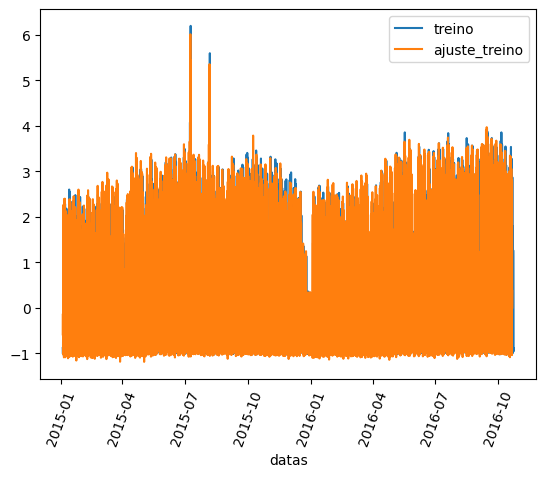

In [31]:
sns.lineplot(x='datas',y=ytreino[:,0],data=bike[0:tamanho_treino],label='treino')
sns.lineplot(x='datas',y=y_ajustado[:15622, 0],data=bike[0:15622],label='ajuste_treino')
plt.xticks(rotation=70)

In [32]:
# Predict Teste
y_predito = recorrente.predict(xteste_novo)

55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


# Visualizando o Gráfico Teste

(array([17106., 17120., 17136., 17150., 17167.]),
 [Text(17106.0, 0, '2016-11-01'),
  Text(17120.0, 0, '2016-11-15'),
  Text(17136.0, 0, '2016-12-01'),
  Text(17150.0, 0, '2016-12-15'),
  Text(17167.0, 0, '2017-01-01')])

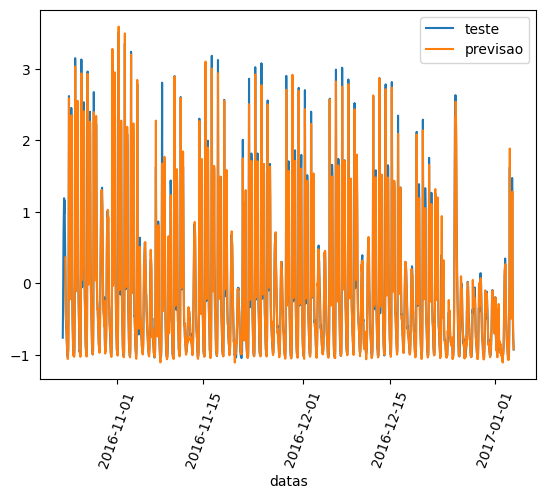

In [33]:
sns.lineplot(x='datas', y=yteste[:,0], data=bike[tamanho_treino:len(bike)], label='teste')
sns.lineplot(x='datas', y=y_predito[:,0], data=bike[tamanho_treino+10:len(bike)], label='previsao')
plt.xticks(rotation=70)

# Utilizando a GRU (unidade recorrente fechada)

A GRU tem uma estrutura mais simples com número menor de camadas de redes neurais dentro dela.

In [34]:
from tensorflow.keras.layers import GRU

In [35]:
recorrente_g = Sequential()

In [36]:
recorrente_g.add(GRU(128,input_shape=(xtreino_novo.shape[1], xtreino_novo.shape[2])))
recorrente_g.add(Dense(units=1)) # Esta é a Camada de Saída

c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


# Compilação da Rede Neural - GRU

In [37]:
recorrente_g.compile(loss='mean_squared_error', optimizer='RMSProp')

In [38]:
# LSTM
recorrente.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 128)            │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 133,380 (521.02 KB)

 Trainable params: 66,689 (260.50 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 66,691 (260.52 KB)

In [39]:
# GRU
recorrente_g.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 128)            │        50,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,433 (197.00 KB)

 Trainable params: 50,433 (197.00 KB)

 Non-trainable params: 0 (0.00 B)

# Fazendo o Ajuste e a Previsão

In [40]:
# Utilizando o GRU
resultado2 = recorrente_g.fit(xtreino_novo, ytreino_novo, validation_data=(xteste_novo, yteste_novo), epochs=100)

Epoch 1/100
490/490 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - loss: 0.2411 - val_loss: 0.0761
Epoch 2/100
490/490 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 0.0710 - val_loss: 0.0392
Epoch 3/100
490/490 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.0508 - val_loss: 0.0269
Epoch 4/100
490/490 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.0438 - val_loss: 0.0271
Epoch 5/100
490/490 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 0.0402 - val_loss: 0.0251
Epoch 6/100
490/490 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 0.0376 - val_loss: 0.0223
Epoch 7/100
490/490 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 0.0358 - val_loss: 0.0256
Epoch 8/100
490/490 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 0.0343 - val_loss: 0.0249
Epoch 9/100
490/490 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 0.0330 - val_loss: 0.0184
Epoch 10/100
490/490 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 0.0321 - val_loss: 0.0269
Epoch 11/100
490/490 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 0.0314 - val_loss: 0.0266
Epoch 12/100
490/490 ━━━━━━━━━

In [41]:
y_predito2 = recorrente_g.predict(xteste_novo)

55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step


<Axes: xlabel='datas'>

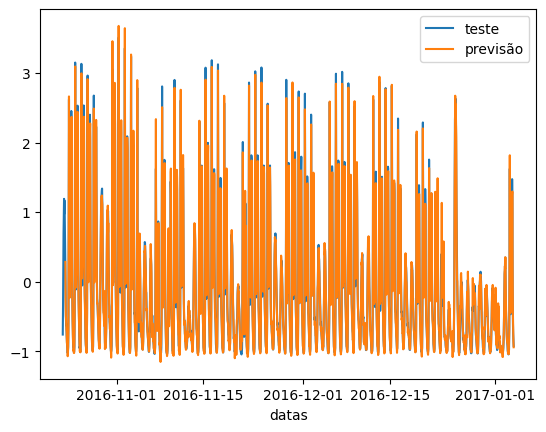

In [42]:
sns.lineplot(x='datas', y=yteste[:,0], data=bike[tamanho_treino:len(bike)], label='teste')
sns.lineplot(x='datas', y=y_predito2[:,0], data=bike[tamanho_treino+10:len(bike)], label='previsão')

In [43]:
print(resultado2.history.keys())

dict_keys(['loss', 'val_loss'])


# Gráfico utilizando LSTM

Text(0, 0.5, 'Custo')

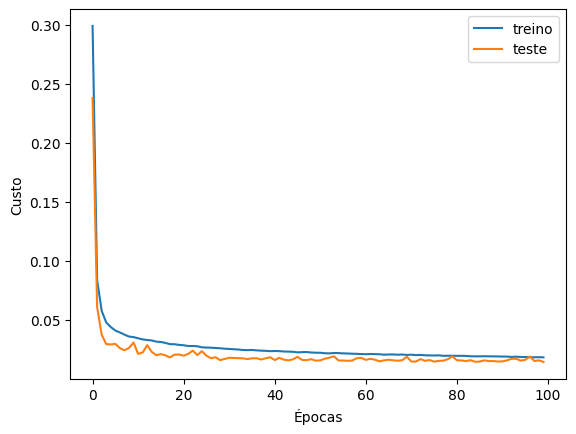

In [44]:
plt.plot(resultado.history['loss'])
plt.plot(resultado.history['val_loss'])
plt.legend(['treino','teste'])
plt.xlabel('Épocas')
plt.ylabel('Custo')

# Gráfico utilizando GRU

Text(0, 0.5, 'Custo')

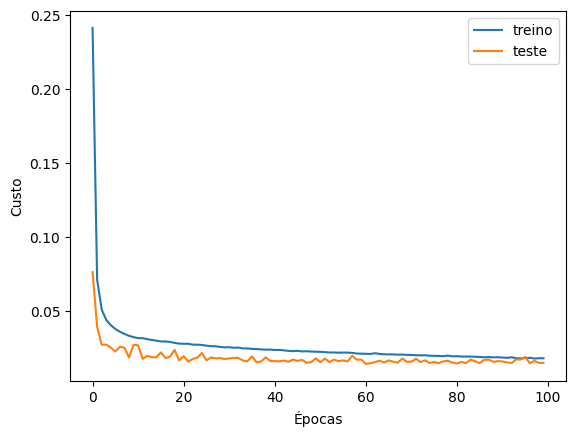

In [45]:
plt.plot(resultado2.history['loss'])
plt.plot(resultado2.history['val_loss'])
plt.legend(['treino','teste'])
plt.xlabel('Épocas')
plt.ylabel('Custo')

Conclusão: 

* No gráfico, temos o valor de custo no eixo y, e o número de épocas no eixo x. E também tivemos um caimento semelhante, tanto para o treino, quanto para o teste, quer dizer que, para os dois casos, nós tivemos resultados satisfatórios. 

* Então, nesse exemplo específico, eu escolheria a GRU, que é um pouco mais rápida e tem menos parâmetros para treinar.

* Neste caso deste projeto, pode até ter demorado um pouco mais para treinar a GRU, devido já ter treinado a LSTM antes, e isso consumiu um pouco de recurso do computador, mas, geralmente, aplicando somente a GRU, a GRU é mais rápida para treinar.